# Churn Prediction — EDA, Preprocessing, Training & Evaluation
**Stack:** pandas · scikit-learn · XGBoost · SHAP · imbalanced-learn  
**Dataset:** Telco Customer Churn (Kaggle)

## 1. Imports

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report, roc_auc_score,
    average_precision_score, RocCurveDisplay,
    PrecisionRecallDisplay, confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap

sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42

## 2. Load & Clean Data

In [12]:
df = pd.read_csv('../data/telco_churn.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
# Drop customer ID — not a feature
df.drop(columns=['customerID'], inplace=True)

# TotalCharges is stored as string — convert and impute
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'TotalCharges nulls: {df["TotalCharges"].isnull().sum()}')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print(f'\nMissing values after cleaning:')
print(df.isnull().sum().sum(), 'total nulls')
df.dtypes

TotalCharges nulls: 11

Missing values after cleaning:
11 total nulls


gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

## 3. Exploratory Data Analysis

Class distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%


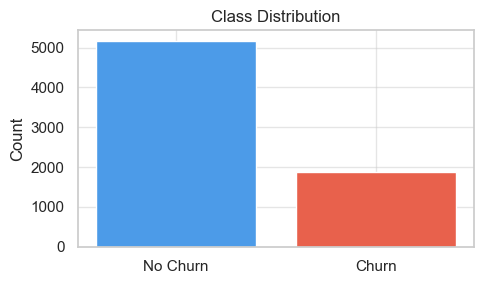

In [14]:
# Class balance
churn_counts = df['Churn'].value_counts()
print('Class distribution:')
print(churn_counts)
print(f'\nChurn rate: {df["Churn"].mean():.1%}')

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['No Churn', 'Churn'], churn_counts.values, color=['#4C9BE8', '#E8614C'])
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

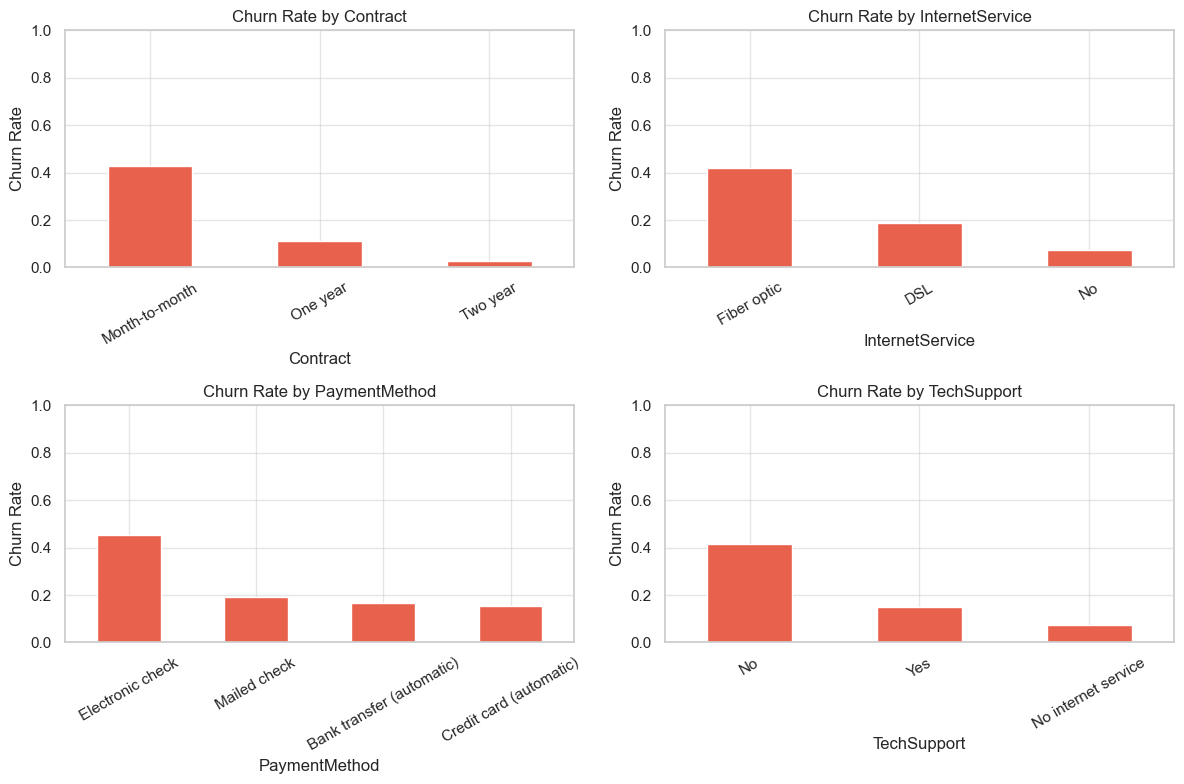

In [15]:
# Churn by key categorical features
cat_features = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flatten(), cat_features):
    churn_rate = df.groupby(feat)['Churn'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=ax, color='#E8614C', edgecolor='white')
    ax.set_title(f'Churn Rate by {feat}')
    ax.set_ylabel('Churn Rate')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

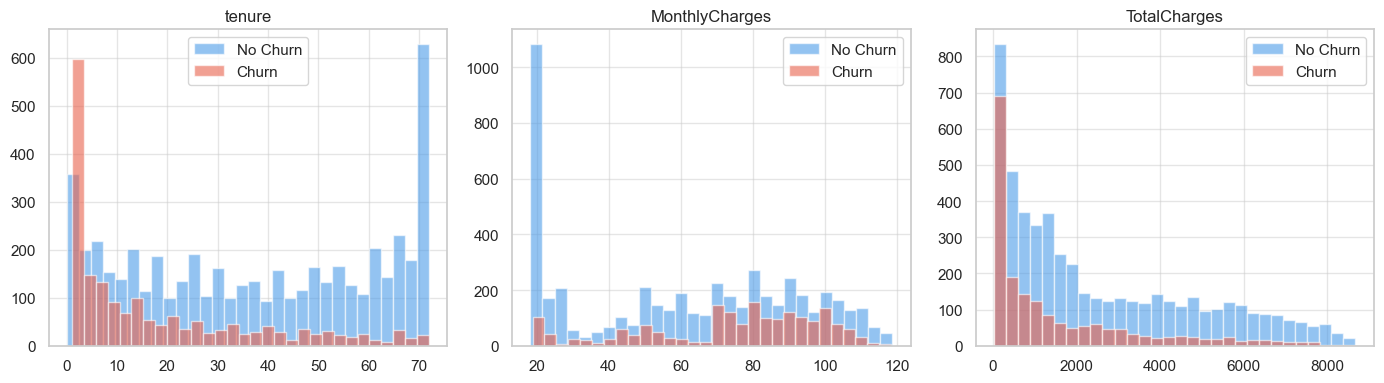

In [16]:
# Numeric feature distributions by churn
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feat in zip(axes, num_features):
    df[df['Churn'] == 0][feat].hist(ax=ax, bins=30, alpha=0.6, label='No Churn', color='#4C9BE8')
    df[df['Churn'] == 1][feat].hist(ax=ax, bins=30, alpha=0.6, label='Churn', color='#E8614C')
    ax.set_title(feat)
    ax.legend()
plt.tight_layout()
plt.show()

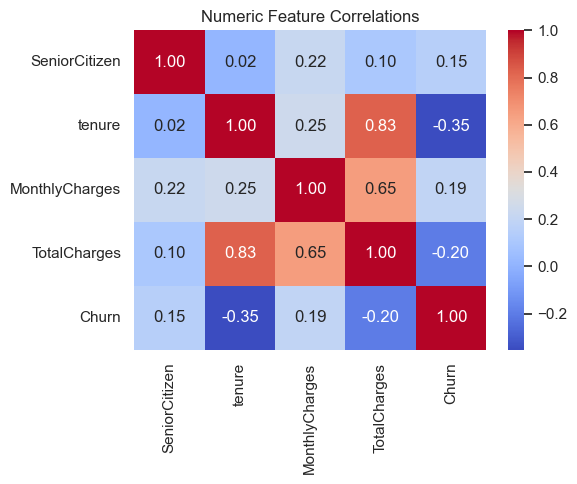

In [17]:
# Correlation heatmap (numeric features only)
num_df = df.select_dtypes(include='number')
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Numeric Feature Correlations')
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [18]:
X = df.drop(columns=['Churn'])
y = df['Churn']

# Train/test split (stratified to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train size: {X_train.shape[0]}')
print(f'Test size:  {X_test.shape[0]}')
print(f'Train churn rate: {y_train.mean():.1%}')
print(f'Test churn rate:  {y_test.mean():.1%}')

Train size: 5634
Test size:  1409
Train churn rate: 26.5%
Test churn rate:  26.5%


In [19]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include='number').columns.tolist()

print(f'Numeric features ({len(num_cols)}):     {num_cols}')
print(f'Categorical features ({len(cat_cols)}): {cat_cols}')

# Pipelines with imputation built in
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Get feature names after one-hot encoding
ohe_features  = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_cols)
feature_names = num_cols + list(ohe_features)

# Verify no NaNs remain
print(f'\nNaNs in X_train_proc: {np.isnan(X_train_proc).sum()}')
print(f'NaNs in X_test_proc:  {np.isnan(X_test_proc).sum()}')
print(f'Total features after encoding: {len(feature_names)}')

Numeric features (4):     ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

NaNs in X_train_proc: 0
NaNs in X_test_proc:  0
Total features after encoding: 45


## 5. SMOTE — Handle Class Imbalance

In [20]:
sm = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = sm.fit_resample(X_train_proc, y_train)

print(f'Before SMOTE: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'After SMOTE:  {dict(zip(*np.unique(y_train_res, return_counts=True)))}')

Before SMOTE: {np.int64(0): np.int64(4139), np.int64(1): np.int64(1495)}
After SMOTE:  {np.int64(0): np.int64(4139), np.int64(1): np.int64(4139)}


## 6. Baseline XGBoost

In [21]:
baseline_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)
baseline_model.fit(X_train_res, y_train_res)

y_proba_base = baseline_model.predict_proba(X_test_proc)[:, 1]
baseline_roc = roc_auc_score(y_test, y_proba_base)
baseline_pr  = average_precision_score(y_test, y_proba_base)
print(f'Baseline ROC-AUC: {baseline_roc:.4f}')
print(f'Baseline PR-AUC:  {baseline_pr:.4f}')

Baseline ROC-AUC: 0.8388
Baseline PR-AUC:  0.6431


## 7. Hyperparameter Tuning

In [22]:
param_grid = {
    'n_estimators':     [100, 200, 300, 400],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1, 0.15],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.2]
}

search = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
    param_distributions=param_grid,
    n_iter=30,
    cv=StratifiedKFold(n_splits=5),
    scoring='average_precision',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train_res, y_train_res)

print(f'Best params: {search.best_params_}')
print(f'Best CV PR-AUC: {search.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 0.9, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.15, 'gamma': 0.2, 'colsample_bytree': 0.9}
Best CV PR-AUC: 0.9374


## 8. Evaluate Tuned Model

In [23]:
best_model  = search.best_estimator_
y_pred      = best_model.predict(X_test_proc)
y_proba     = best_model.predict_proba(X_test_proc)[:, 1]

tuned_roc = roc_auc_score(y_test, y_proba)
tuned_pr  = average_precision_score(y_test, y_proba)

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
print(f'Baseline ROC-AUC: {baseline_roc:.4f}  →  Tuned ROC-AUC: {tuned_roc:.4f}')
print(f'Baseline PR-AUC:  {baseline_pr:.4f}  →  Tuned PR-AUC:  {tuned_pr:.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

    No Churn       0.85      0.86      0.85      1035
       Churn       0.59      0.59      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409

Baseline ROC-AUC: 0.8388  →  Tuned ROC-AUC: 0.8290
Baseline PR-AUC:  0.6431  →  Tuned PR-AUC:  0.6251


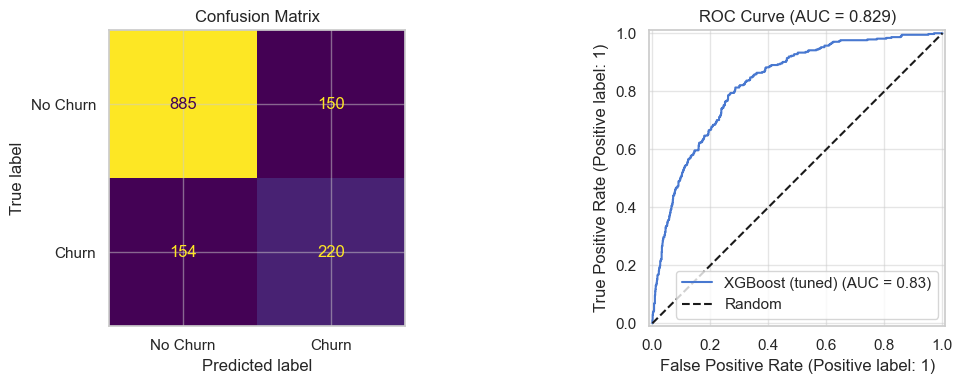

In [24]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Churn', 'Churn'],
    ax=axes[0], colorbar=False
)
axes[0].set_title('Confusion Matrix')

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name='XGBoost (tuned)')
axes[1].plot([0,1],[0,1],'k--', label='Random')
axes[1].set_title(f'ROC Curve (AUC = {tuned_roc:.3f})')
axes[1].legend()

plt.tight_layout()
plt.show()

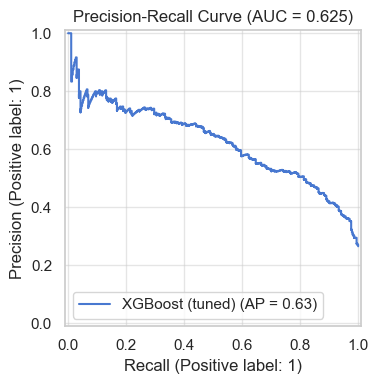

In [25]:
# Precision-Recall curve
fig, ax = plt.subplots(figsize=(6, 4))
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=ax, name='XGBoost (tuned)')
ax.set_title(f'Precision-Recall Curve (AUC = {tuned_pr:.3f})')
plt.tight_layout()
plt.show()

## 9. SHAP Explainability

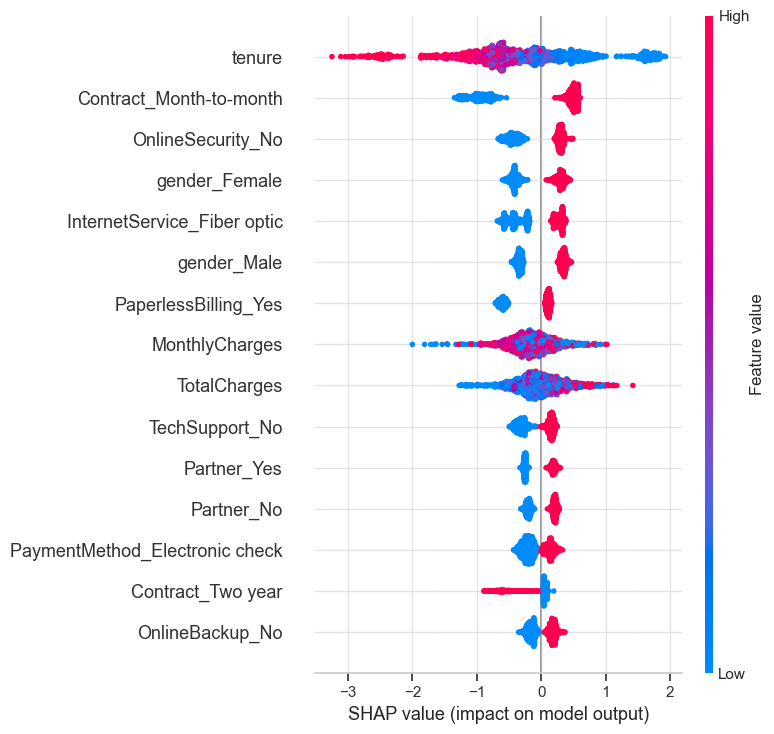

In [26]:
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_proc)

# Global feature importance — summary plot
plt.figure()
shap.summary_plot(
    shap_values, X_test_proc,
    feature_names=feature_names,
    max_display=15,
    show=True
)

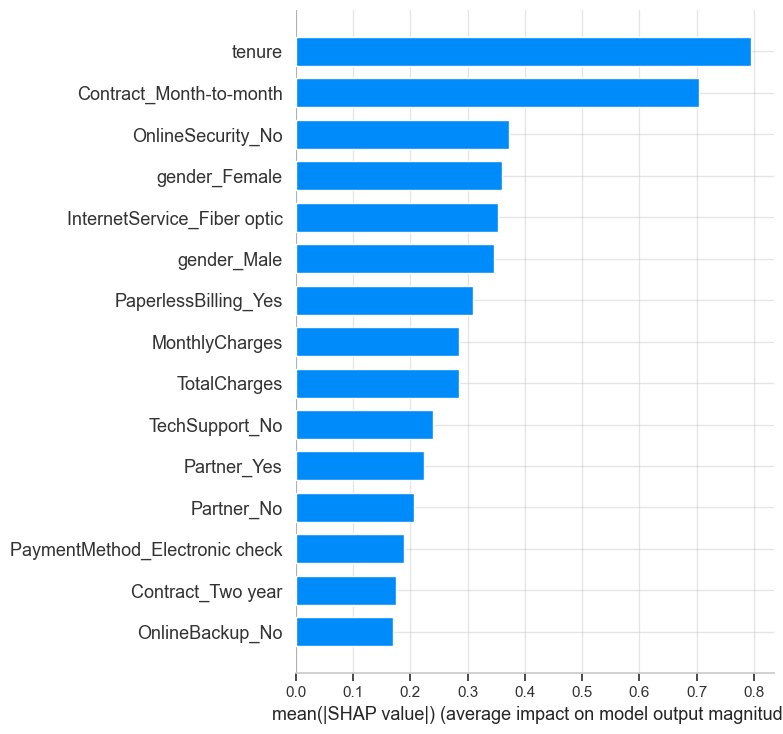

In [27]:
# Bar chart of mean absolute SHAP values
shap.summary_plot(
    shap_values, X_test_proc,
    feature_names=feature_names,
    plot_type='bar',
    max_display=15,
    show=True
)

True label: No Churn
Predicted probability: 0.005


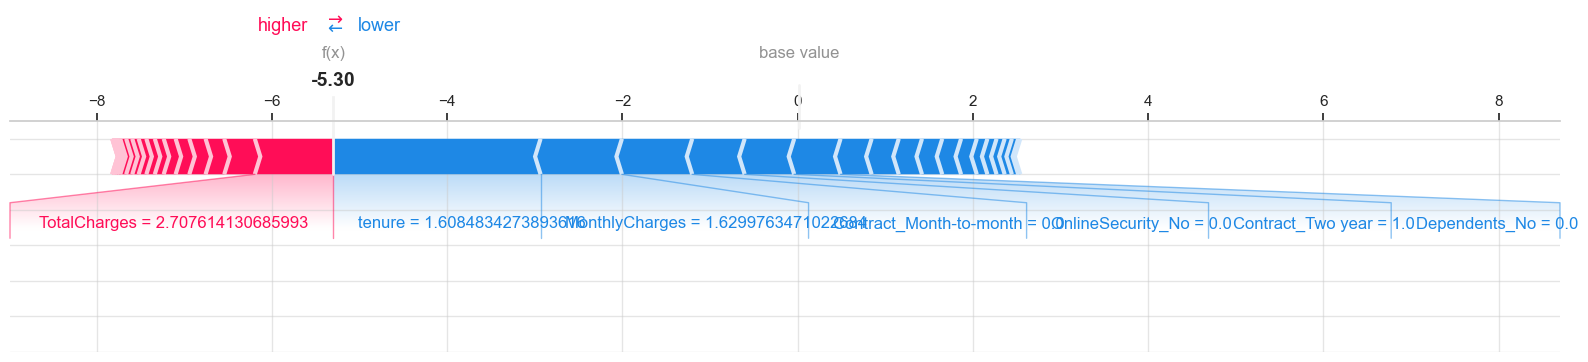

In [28]:
# Single prediction explanation — index 0 (change to explore others)
idx = 0
print(f'True label: {"Churn" if y_test.iloc[idx] == 1 else "No Churn"}')
print(f'Predicted probability: {y_proba[idx]:.3f}')

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test_proc[idx],
    feature_names=feature_names,
    matplotlib=True
)

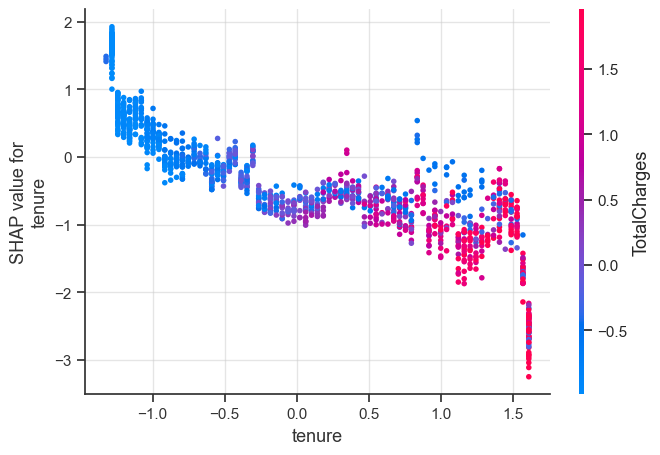

In [29]:
# Dependence plot — tenure vs churn risk
shap.dependence_plot(
    'tenure', shap_values, X_test_proc,
    feature_names=feature_names,
    show=True
)

## 10. Save Artifacts

In [30]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(best_model,    '../models/churn_model.pkl')
joblib.dump(preprocessor,  '../models/preprocessor.pkl')
joblib.dump(feature_names, '../models/feature_names.pkl')

print('Artifacts saved:')
print('  models/churn_model.pkl')
print('  models/preprocessor.pkl')
print('  models/feature_names.pkl')
print(f'\nFinal model — ROC-AUC: {tuned_roc:.4f} | PR-AUC: {tuned_pr:.4f}')

Artifacts saved:
  models/churn_model.pkl
  models/preprocessor.pkl
  models/feature_names.pkl

Final model — ROC-AUC: 0.8290 | PR-AUC: 0.6251
